# Baseline and first gbm model 

# Table of Contents
- [ 1 - Introduction](#1)
  - [ 1.1 parameters](#1-1)
  - [ 1.2 Importing the necessary libraries](#1-2)
- [ 2 - Loading the training dataset](#2)
- [ 3 - Exploratory Data Analysis and Data Preparation](#3)
  - [ 3.1 Inspecting the target variable](#3-1)
  - [ 3.2 checking duplicate rows](#3-2)
  - [ 3.3 Identifying numerical and categorical features](#3-3)
  - [ 3.5 Train / validation split](#3-5)
- [ 4 - Modeling Pipeline and Experiment Tracking](#3)
  - [ 4.1 Model Configuration ](#4-1)
  - [ 4.2 Model Training and MLflow Tracking ](#4-2)
- [ 5 - Model performance metrics](#5)
  - [ 5.1 predictions ](#5-1)
  - [ 5.2 Cumulative gain and lift ](#5-2)
  - [ 5.3 Confusion matrix by threshold ](#5-3)
  - [ 5.4 ROC/AUC ](#5-3)
---

<a id='1'></a>
## 1 - Introduction

<a id='1-1'></a>
### 1.1 Parameters

In [1]:
target = 'activity'
created_features = ['volume']
columns_to_drop = [] 

<a id='1-2'></a>
### 1.2 Importing the necessary libraries

In [2]:
# =========================
# Standard library
# =========================
import os
import sys
from pathlib import Path


# =========================
# Data manipulation
# =========================
import numpy as np
import pandas as pd


# =========================
# Configuration / serialization
# =========================
import yaml


# =========================
# Machine learning - preprocessing
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, FunctionTransformer, LabelEncoder)
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.base import BaseEstimator, ClassifierMixin, clone


# =========================
# Machine learning - modeling
# =========================
from sklearn.tree import DecisionTreeClassifier


# =========================
# Machine learning - evaluation
# =========================
from sklearn.metrics import roc_auc_score


# =========================
# Machine learning - data splitting
# =========================
from sklearn.model_selection import train_test_split


# =========================
# Experiment tracking
# =========================
import mlflow
from mlflow.models.signature import infer_signature
import mlflow.sklearn


# =========================
# Local project path setup
# =========================
sys.path.extend([str(Path.cwd().parent)])


# =========================
# Local project modules
# =========================
import data
from utils import (
    lift_table,
    plot_lift,
    plot_roc_mpl,
    plot_roc_plotly,
    threshold_table,
    add_volume,
    LabelEncodedClassifier,
)

<a id='2'></a>
## 2 - Loading the training and test dataset

In [3]:
train_data = pd.read_excel(io=os.path.join(os.path.dirname(data.__file__), "dataset.xlsx"))

In [4]:
train_data

,height,width,depth,weight,activity
0,90.5,42.0,2.0,1.25,mlp
1,60.0,50.0,2.0,1.20,mlp
2,80.0,59.6,2.0,7.40,mlp
3,46.0,46.0,2.0,1.45,mlp
4,93.0,21.0,2.0,1.30,mlp
...,...,...,...,...,...
895,81.0,295.0,175.0,84.00,meuble
896,100.0,170.0,207.0,41.00,meuble
897,125.0,200.0,215.0,96.30,meuble
898,80.0,270.0,270.0,93.00,meuble


# 3 - Exploratory Data Analysis and Data Preparation

## 3.1 Inspecting the target variable

In [5]:
(train_data[target].value_counts(normalize=True)*100).round(2)

activity
mlp       33.33
deco      33.33
meuble    33.33
Name: proportion, dtype: float64

In [6]:
train_data

,height,width,depth,weight,activity
0,90.5,42.0,2.0,1.25,mlp
1,60.0,50.0,2.0,1.20,mlp
2,80.0,59.6,2.0,7.40,mlp
3,46.0,46.0,2.0,1.45,mlp
4,93.0,21.0,2.0,1.30,mlp
...,...,...,...,...,...
895,81.0,295.0,175.0,84.00,meuble
896,100.0,170.0,207.0,41.00,meuble
897,125.0,200.0,215.0,96.30,meuble
898,80.0,270.0,270.0,93.00,meuble


## 3.2 checking duplicate rows

In [7]:
n_duplicates = train_data.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 18


## 3.3 Identifying numerical and categorical features

In [8]:
numerical_features   = [c for c in train_data.select_dtypes(include="number").columns if c not in [target] + columns_to_drop]
categorical_features = [c for c in train_data.select_dtypes(exclude="number").columns if c not in [target] + columns_to_drop]

print(f"Numerical   ({len(numerical_features)}):", numerical_features)
print(f"Categorical ({len(categorical_features)}):", categorical_features)

Numerical   (4): ['height', 'width', 'depth', 'weight']
Categorical (0): []


## 3.4 Missing values per column

In [9]:
missing_summary = pd.DataFrame({
    "missing_count":      train_data.isna().sum(),
    "missing_percentage": train_data.isna().mean() * 100,
})


missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
    .round({"missing_percentage": 2})
)

missing_summary

,missing_count,missing_percentage


## 3.5 Train / validation split

In [10]:
X = train_data.drop(columns=target)
y = train_data[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

print("\nRépartition des classes - train")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

print("\nRépartition des classes - validation")
print(
    y_val.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

Training set shape:   (720, 4)
Validation set shape: (180, 4)

Répartition des classes - train
activity
mlp       33.33%
meuble    33.33%
deco      33.33%
Name: proportion, dtype: object

Répartition des classes - validation
activity
deco      33.33%
meuble    33.33%
mlp       33.33%
Name: proportion, dtype: object


# 4 Modeling Pipeline and Experiment Tracking

## 4.1 Model Configuration

In [11]:
with open(Path.cwd().parent / "config.yaml") as f:
    config = yaml.safe_load(f)

def build_classifier(cfg):
    mtype  = cfg["model"]["type"]
    params = cfg["params"][mtype]

    if mtype == "decision_tree":
        return DecisionTreeClassifier(**params)
    if mtype == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(**params)
    if mtype == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(**params)
    if mtype == "catboost":
        from catboost import CatBoostClassifier
        return CatBoostClassifier(verbose=0, **params)

    raise ValueError(f"Unknown model type: {mtype}")

classifier = build_classifier(config)

print("── Expérience ──")
print(f"Experiment name : {config.get('experiment_name')}")
print(f"Description     : {config.get('description')}")

print("── Modèle sélectionné ──")
print(f"Type       : {config['model']['type']}")
print(f"Classifier : {type(classifier).__name__}")
print(f"Paramètres : {classifier.get_params()}")

── Expérience ──
Experiment name : test_axa
Description     : first attempt with lightgbm
── Modèle sélectionné ──
Type       : lightgbm
Classifier : LGBMClassifier
Paramètres : {'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 0.9, 'importance_type': 'split', 'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 31, 'objective': 'multiclass', 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.9, 'subsample_for_bin': 200000, 'subsample_freq': 0}


## 4.2 Model Training and MLflow Tracking

In [12]:
numerical_features = numerical_features + created_features

pp = config["preprocessing"]["imputers"]

transformers = [(col, SimpleImputer(**spec), [col]) for col, spec in pp.items()]

if categorical_features:
    transformers.append(("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features))

remaining = [c for c in numerical_features if c not in pp]
if remaining:
    transformers.append(("keep", "passthrough", remaining))

preprocessor = ColumnTransformer(transformers)

pipeline = Pipeline(steps=[
    ("feature_engineering", FunctionTransformer(add_volume)),
    ("preprocessor",        preprocessor),
    ("classifier",          LabelEncodedClassifier(classifier)),
])


print("── Feature engineering ──")
print("  WeightedPastDue = NumberOfTime30-59DaysPastDueNotWorse + 3 * NumberOfTimes90DaysLate\n")

print("── Préprocesseur ──")
print(f"  Imputers      ({len(pp):>2}) : {list(pp.keys())}")
print(f"  Catégorielles ({len(categorical_features):>2}) : {categorical_features}")
print(f"  Passthrough   ({len(remaining):>2}) : {remaining}")
print(f"  Classifier    : {type(classifier).__name__}\n")

print("── Pipeline ──")
for i, (name, step) in enumerate(pipeline.steps):
    print(f"  [{i}] {name:20s} → {type(step).__name__}")

── Feature engineering ──
  WeightedPastDue = NumberOfTime30-59DaysPastDueNotWorse + 3 * NumberOfTimes90DaysLate

── Préprocesseur ──
  Imputers      ( 1) : ['height']
  Catégorielles ( 0) : []
  Passthrough   ( 4) : ['width', 'depth', 'weight', 'volume']
  Classifier    : LGBMClassifier

── Pipeline ──
  [0] feature_engineering  → FunctionTransformer
  [1] preprocessor         → ColumnTransformer
  [2] classifier           → LabelEncodedClassifier


In [13]:
# =============================================================================
# MLFLOW TRACKING
# =============================================================================
# Logs params + train/val metrics for the current pipeline run.
# All behaviour is driven by `config` (loaded from config.yaml).
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Tracking backend + experiment
# -----------------------------------------------------------------------------
(Path.cwd().parent / "mlruns").mkdir(exist_ok=True)
mlflow.set_tracking_uri((Path.cwd().parent / "mlruns").as_uri())
mlflow.set_experiment(config["experiment_name"])


# -----------------------------------------------------------------------------
# 2. Open a run — everything below is attached to this run
# -----------------------------------------------------------------------------
with mlflow.start_run(run_name=config["run_name"],
                      description=config["description"]):

    # -------------------------------------------------------------------------
    # 2.a  Log hyperparameters
    # -------------------------------------------------------------------------
    model_type = config["model"]["type"]
    mlflow.log_params({"model_type": model_type, **config["params"][model_type]})
    mlflow.log_params({f"impute__{k}": v for k, v in config["preprocessing"].items()})

    # -------------------------------------------------------------------------
    # 2.b  Fit pipeline — early stopping pour les modèles de boosting
    # -------------------------------------------------------------------------
    if model_type == "decision_tree":
        pipeline.fit(X_train, y_train)

    else:
        es = config["early_stopping_rounds"]

        # Fit des étapes de preprocessing puis transform de X_val
        pipeline[:-1].fit(X_train, y_train) 
        X_train_t = pipeline[:-1].transform(X_train)
        X_val_t   = pipeline[:-1].transform(X_val)

        wrapper = pipeline.named_steps["classifier"]

        if model_type == "lightgbm":
            import lightgbm as lgb
            wrapper.fit(
                X_train_t, y_train,
                eval_set=[(X_val_t, y_val)],
                callbacks=[lgb.early_stopping(es), lgb.log_evaluation(0)],
            )

        elif model_type == "xgboost":
            classifier.set_params(early_stopping_rounds=es)
            wrapper.fit(
                X_train_t, y_train,
                eval_set=[(X_val_t, y_val)],
                verbose=False,
            )

        elif model_type == "catboost":
            wrapper.fit(
                X_train_t, y_train,
                eval_set=[(X_val_t, y_val)],
                early_stopping_rounds=es,
                verbose=False,
            )

        best_iter = (
            getattr(wrapper.classifier_, "best_iteration_", None)
            or getattr(wrapper.classifier_, "best_iteration", None)
            or 0
        )
        print(f"  [{model_type}] best iteration = {best_iter}  (patience = {es})")
        mlflow.log_param("early_stopping_rounds", es)
        mlflow.log_metric("best_iteration", int(best_iter))

    # -------------------------------------------------------------------------
    # 2.c  Prédictions train / val
    # -------------------------------------------------------------------------
    y_train_proba = pipeline.predict_proba(X_train)
    y_val_proba   = pipeline.predict_proba(X_val)

    # -------------------------------------------------------------------------
    # 2.d  AUC — train & val
    # -------------------------------------------------------------------------
    mlflow.log_metric("train_auc", roc_auc_score(y_train, y_train_proba, multi_class="ovr", average="macro"))
    mlflow.log_metric("val_auc",   roc_auc_score(y_val,   y_val_proba, multi_class="ovr", average="macro"))

    # -------------------------------------------------------------------------
    # 2.e  Lift & capture rate at top K% — train & val — multiclass
    # -------------------------------------------------------------------------

    class_names = pipeline.named_steps["classifier"].classes_

    for split, y, proba in [
        ("train", y_train, y_train_proba),
        ("val",   y_val,   y_val_proba),
    ]:
        y = np.asarray(y)
        n = len(y)

        for class_idx, class_name in enumerate(class_names):
            y_binary = (y == class_name).astype(int)
            class_proba = proba[:, class_idx]

            order = np.argsort(-class_proba)
            y_sorted = y_binary[order]

            baseline = y_binary.mean()
            total_pos = y_binary.sum()

            if total_pos == 0 or baseline == 0:
                continue

            for top in config["tops"]:
                k = int(round(n * top / 100))
                k = max(k, 1)

                captured = int(y_sorted[:k].sum())

                lift = (captured / k) / baseline
                capture_rate = captured / total_pos * 100

                mlflow.log_metric(
                    f"{split}_lift_top_{top}_class_{class_name}",
                    lift,
                )

                mlflow.log_metric(
                    f"{split}_capture_top_{top}_class_{class_name}",
                    capture_rate,
                )

    # -------------------------------------------------------------------------
    # 2.f  Persist the fitted pipeline as an MLflow artifact
    # -------------------------------------------------------------------------
    
    signature = infer_signature(X_train.head(5), pipeline.predict_proba(X_train.head(5)))
    mlflow.sklearn.log_model(
        pipeline,
        name="model",
        signature=signature,
        input_example=X_train.head(5),
    )

c:\Users\berka\Desktop\test\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 822
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 5
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/05/01 14:06:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistenc

In [ ]:
exp = mlflow.get_experiment_by_name("test_axa")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
runs[["run_id", "tags.mlflow.runName", "start_time", "metrics.val_auc"]] 

,run_id,tags.mlflow.runName,start_time,metrics.val_auc
0,3d04c60c82c348b2895c2397a4d611a0,lightgbm,2026-05-01 12:06:27.682000+00:00,0.939722
1,b1c2eedd3ae44cea81fba05a961a0c64,lightgbm,2026-05-01 12:05:16.062000+00:00,0.913565


# 5 Model performance metrics

In [16]:
model = mlflow.sklearn.load_model("runs:/3d04c60c82c348b2895c2397a4d611a0/model")

In [17]:
model.predict_proba(train_data)

c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.10589088, 0.01498499, 0.87912413],
       [0.01705265, 0.00555549, 0.97739185],
       [0.16169186, 0.02287463, 0.81543351],
       ...,
       [0.0037272 , 0.99269821, 0.00357459],
       [0.0026826 , 0.9938931 , 0.0034243 ],
       [0.30339439, 0.67968797, 0.01691764]], shape=(900, 3))

## 5.1 predictions

In [18]:
y_train_proba = pipeline.predict_proba(X_train)
y_val_proba = pipeline.predict_proba(X_val)

c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5.2 Cumulative gain and lift

In [19]:
plot_lift(y_val, y_val_proba).show()

In [20]:
lift_table(
    y_val=y_val,
    y_val_proba=y_val_proba,       
    y_train=y_train,
    y_train_proba=y_train_proba,
    tops=[1, 2, 5, 10, 20],
    class_name="mlp",
)

,top_%,score_threshold,captured,capture_%,lift,lift_train,score_threshold_train
0,1,0.9862,2,3.33,3.00,3.0,0.9842
1,2,0.9838,4,6.67,3.00,3.0,0.9813
2,5,0.9760,9,15.00,3.00,3.0,0.9704
3,10,0.9546,17,28.33,2.83,3.0,0.9462
4,20,0.8118,33,55.00,2.75,3.0,0.8649


## 5.3 Confusion matrix by threshold

In [21]:
threshold_table(y_val, y_val_proba, class_name="mlp")

,threshold,TP,FP,TN,FN,precision,recall,specificity,f1,accuracy
0,0.05,58,36,84,2,0.617021,0.966667,0.700000,0.753247,0.788889
1,0.10,56,32,88,4,0.636364,0.933333,0.733333,0.756757,0.800000
2,0.15,55,29,91,5,0.654762,0.916667,0.758333,0.763889,0.811111
3,0.20,54,28,92,6,0.658537,0.900000,0.766667,0.760563,0.811111
4,0.25,54,25,95,6,0.683544,0.900000,0.791667,0.776978,0.827778
5,0.30,54,22,98,6,0.710526,0.900000,0.816667,0.794118,0.844444
6,0.35,53,20,100,7,0.726027,0.883333,0.833333,0.796992,0.850000
7,0.40,52,18,102,8,0.742857,0.866667,0.850000,0.800000,0.855556
8,0.45,51,15,105,9,0.772727,0.850000,0.875000,0.809524,0.866667
9,0.50,50,12,108,10,0.806452,0.833333,0.900000,0.819672,0.877778


## 5.4 ROC/AUC

<Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate (Positive label: 1)', ylabel='True Positive Rate (Positive label: 1)'>

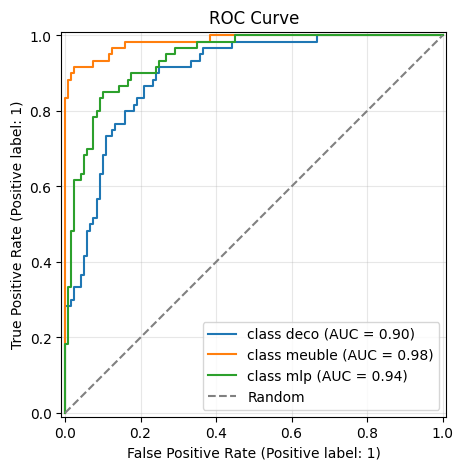

In [22]:
plot_roc_mpl(y_val, y_val_proba)